# MCMC Batch Cases
---
Repeats the full inference pipeline on several held-out simulations. For each case: mock observation $\rightarrow$ MCMC $\rightarrow$ posterior $\rightarrow$ LinearND ionization history.

Two batches:
- Random - Five randomly chosen held-out simulations.
- Central - The five held-out simulations nearest the centre of parameter space, where the emulator has the most training support.

Produces two figures:
- Random combined true and posterior mean ionization history
- Most central combined true and posterior mean ionization history

More information about the package can be found here: [Documentation](https://reionemu.org/)

## Imports

In [1]:
import sys
import json

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.interpolate import LinearNDInterpolator
import emcee

from reionemu import load_training_arrays, MCDropoutEmulator, Normalizer, predict_mc

## Paths, Configs, and Constants

In [2]:
# Paths
from config import H5_PATH, MODEL_PATH, NORM_PATH, FIG_DIR, EXPERIMENT_NAME, make_dirs
from config import HELDOUT_INDICES_PATH, RECORDS_DIR

# Constants
from config import SEED, PARAM_BOUNDS, param_order, device, N_MC_EVAL
from config import N_DIM, N_WALKERS, N_STEPS, DISCARD, THIN


make_dirs()

## Seeding

In [3]:
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python:\t\t{sys.version.split()[0]}")
print("-" * 30)
print(f"NumPy:\t\t{np.__version__}")
print(f"PyTorch:\t{torch.__version__}")
print(f"emcee:\t\t{emcee.__version__}")
print("-" * 30)
print(f"Global Seed:\t{SEED}")

Python:		3.13.1
------------------------------
NumPy:		2.5.2
PyTorch:	2.13.0
emcee:		3.1.6
------------------------------
Global Seed:	42


## Load Trained Model

In [4]:
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)

model = MCDropoutEmulator(**ckpt["model_config"])
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

norms = {
    "X": Normalizer(
        mean=np.load(NORM_PATH / "X_mean.npy"),
        std=np.load(NORM_PATH / "X_std.npy"),
    ),
    "Y": None,
}

X, Y, ell = load_training_arrays(H5_PATH)
heldout_indices = np.load(HELDOUT_INDICES_PATH)
X_heldout = X[heldout_indices]
Y_heldout = Y[heldout_indices]

print(f"Model:\n{MODEL_PATH}")
print(f"Architecture:\t{ckpt['model_config']}")
print(f"Held-Out Samples:\t{len(heldout_indices)}")

Model:
/Users/robertxpearce/Desktop/Research/LEADS Lab/reionemu/reionemu-pasa-2026/checkpoints/pearce_2026_reionemu_mc_dropout/mc_dropout_n_mc_201_epochs_1000_early_stop_150/model.pt
Architecture:	{'input_dim': 4, 'output_dim': 5, 'hidden_dim': 20, 'num_hidden_layers': 2, 'activation': 'relu', 'dropout_rate': 0.1}
Held-Out Samples:	200


## Likelihood Functions

In [5]:
def log_prior(theta):
    theta = np.asarray(theta)

    if np.any(theta < PARAM_BOUNDS[:, 0]) or np.any(theta > PARAM_BOUNDS[:, 1]):
        return -np.inf

    return 0.0

def predict_emulator(theta):
    theta = np.array(theta, dtype=np.float32)

    pred_dl, pred_std, _, _ = predict_mc(
        theta,
        model,
        norms["X"].mean,
        norms["X"].std,
        normalize_X=True,
        n_mc_samples=N_MC_EVAL,
        device=device,
    )

    return pred_dl, pred_std


def log_likelihood(theta, observed_dl, sigma_obs):
    model_dl, emulator_std = predict_emulator(theta)

    sigma_total = np.sqrt(sigma_obs**2 + emulator_std**2)

    residual = observed_dl - model_dl

    chi2 = np.sum((residual / sigma_total) ** 2)
    log_det = np.sum(np.log(2.0 * np.pi * sigma_total**2))

    return -0.5 * (chi2 + log_det)


def log_probability(theta, observed_dl, sigma_obs):
    lp = log_prior(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood(theta, observed_dl, sigma_obs)

## Build Lookup Table

In [6]:
def normalize_params(X):
    """
    Min-max scaling: u = (x-lo)/(hi-lo)
    """
    X = np.asarray(X)
    return (X - PARAM_BOUNDS[:, 0]) / (PARAM_BOUNDS[:, 1] - PARAM_BOUNDS[:, 0])


X_rows = []
tau_rows = []
xe_rows = []
z_grid = None

with h5py.File(H5_PATH, "r") as h5f:
    sims = h5f["sims"]

    sim_names = sorted(
        sims.keys(),
        key=lambda s: int(s[3:]) if s.startswith("sim") and s[3:].isdigit() else s,
    )

    dataset_sim_names = sorted(sims.keys())

    for sim in sim_names:
        g = sims[sim]

        theta = [
            float(g[f"params/{p}"][()])
            for p in param_order
        ]

        # Tau
        tau = float(g["output/tau"][()])

        # Ionization history
        z_sim = np.array(g["output/zval_list"][()], dtype=float)
        xe = np.array(g["output/xmval_list"][()], dtype=float)

        z_order = np.argsort(z_sim)
        z_sim = z_sim[z_order]
        xe = xe[z_order]

        if z_grid is None:
            z_grid = z_sim
        else:
            if len(z_sim) != len(z_grid) or not np.allclose(z_sim, z_grid):
                xe = np.interp(z_grid, z_sim, xe)

        X_rows.append(theta)
        tau_rows.append(tau)
        xe_rows.append(xe)

X_sim = np.array(X_rows, dtype=float)
tau_sim = np.array(tau_rows, dtype=float)
xe_sim = np.array(xe_rows, dtype=float)

print("X_sim shape:", X_sim.shape)
print("tau_sim shape:", tau_sim.shape)
print("xe_sim shape:", xe_sim.shape)
print("z_grid shape:", z_grid.shape)

assert X_sim.shape[1] == 4
assert tau_sim.shape[0] == X_sim.shape[0]
assert xe_sim.shape[0] == X_sim.shape[0]
assert xe_sim.shape[1] == len(z_grid)

Xn = normalize_params(X_sim)
ih_interp = LinearNDInterpolator(Xn, xe_sim, fill_value=np.nan)

X_sim shape: (1000, 4)
tau_sim shape: (1000,)
xe_sim shape: (1000, 26)
z_grid shape: (26,)


## Central-Case Ordering

In [7]:
u = (X_heldout - PARAM_BOUNDS[:, 0]) / (PARAM_BOUNDS[:, 1] - PARAM_BOUNDS[:, 0])
dist = np.linalg.norm(u - 0.5, axis=1)

central_order = np.argsort(dist)

print("Five held-out simulations closest to the centre:")
for pos in central_order[:5]:
    print(f"\tTest-Set Index: {pos} \t Global Dataset Index: {heldout_indices[pos]} \t Dist {dist[pos]:.3f}")

Five held-out simulations closest to the centre:
	Test-Set Index: 37 	 Global Dataset Index: 106 	 Dist 0.174
	Test-Set Index: 11 	 Global Dataset Index: 32 	 Dist 0.197
	Test-Set Index: 30 	 Global Dataset Index: 450 	 Dist 0.208
	Test-Set Index: 0 	 Global Dataset Index: 560 	 Dist 0.226
	Test-Set Index: 90 	 Global Dataset Index: 111 	 Dist 0.238


## MCMC Configuration

In [8]:
NSTEPS = N_STEPS
NWALKERS = N_WALKERS
NDIM = N_DIM

DISCARD = DISCARD
THIN = THIN

N_CASES = 5

print(f"{N_CASES} cases x {NWALKERS} walkers x {NSTEPS:,} steps")
print(f"discard={DISCARD}, thin={THIN}")

5 cases x 32 walkers x 30,000 steps
discard=1000, thin=100


## Case Pipeline

In [9]:
def run_cases(case_idx, rng):
    """
    Full pipeline per case: mock observation -> MCMC -> posterior -> LinearND
    ionization history.
    """
    results = []

    for n, idx in enumerate(case_idx):
        case_true_params = X_heldout[idx]
        case_observed_dl = np.exp(Y_heldout[idx])
        case_sigma_obs   = 0.10 * case_observed_dl

        # MCMC
        case_initial_pos = case_true_params + 1e-2 * rng.standard_normal((NWALKERS, NDIM))
        for j, (low, high) in enumerate(PARAM_BOUNDS):
            case_initial_pos[:, j] = np.clip(case_initial_pos[:, j], low, high)

        case_sampler = emcee.EnsembleSampler(NWALKERS, NDIM, log_probability, args=(case_observed_dl, case_sigma_obs))

        print(f"\n[{n + 1}/{len(case_idx)}] test-set idx {idx} - running {NSTEPS:,} steps...")
        case_sampler.run_mcmc(case_initial_pos, NSTEPS, progress=True)

        # Posterior
        case_samples = case_sampler.get_chain(discard=DISCARD, thin=THIN, flat=True)
        case_posterior_mean = case_samples.mean(axis=0)

        # Normalize + LinearND ionization history
        case_samples_n = normalize_params(case_samples)
        case_true_n = normalize_params(case_true_params[None, :])
        case_posterior_mean_n = normalize_params(case_posterior_mean[None, :])

        ih_true = ih_interp(case_true_n)[0]
        ih_mean = ih_interp(case_posterior_mean_n)[0]
        ih_post = ih_interp(case_samples_n)

        outside_hull = np.isnan(ih_post).any(axis=1)
        ih_p16 = np.nanpercentile(ih_post, 16, axis=0)
        ih_p84 = np.nanpercentile(ih_post, 84, axis=0)
        print(f"\tacceptance={np.mean(case_sampler.acceptance_fraction):.3f} \t out-of-hull={outside_hull.mean() * 100:.1f}%")

        results.append(dict(
            idx=int(idx), global_idx=int(heldout_indices[idx]),
            sim_name=dataset_sim_names[heldout_indices[idx]],
            true_params=case_true_params, ih_true=ih_true, ih_mean=ih_mean,
            ih_p16=ih_p16, ih_p84=ih_p84, nan_frac=float(outside_hull.mean()),
        ))

    return results


def plot_cases(results, filename):
    """
    Combined ionization-history figure: solid = true, dashed = posterior mean,
    band = 68% credible interval, one color per simulation.
    """
    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    fig, ax = plt.subplots(figsize=(7.1, 4.5))

    for r, c in zip(results, colors):
        ax.fill_between(z_grid, r["ih_p16"], r["ih_p84"], color=c, alpha=0.12, linewidth=0)
        ax.plot(z_grid, r["ih_mean"], "--", color=c, linewidth=1.2)
        ax.plot(z_grid, r["ih_true"], "-",  color=c, linewidth=1.2,
                label=r["sim_name"])

    ax.set_xlim(5, 12)
    ax.set_xlabel("Redshift $z$")
    ax.set_ylabel(r"Mean Ionized Fraction")
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

    # Legend 1
    leg1 = ax.legend(frameon=False, fontsize=6, ncol=2, loc="lower right", title="Held-out simulation")
    plt.setp(leg1.get_title(), fontsize=7)
    ax.add_artist(leg1)

    # Legend 2
    style_handles = [
        Line2D([0], [0], color="0.3", linestyle="-",  linewidth=1.2, label="True Parameters"),
        Line2D([0], [0], color="0.3", linestyle="--", linewidth=1.2, label="MCMC Posterior Mean"),
        Patch(facecolor="0.3", alpha=0.25, label="68% Band"),
    ]
    ax.legend(handles=style_handles, frameon=False, fontsize=6.5, loc="upper left")

    fig.savefig(FIG_DIR / filename, format="pdf", bbox_inches="tight")
    plt.show()


def case_percent_errors(results):
    """
    Mean fractional error on x_i(z) where reionization is in progress, per case.
    Restricted to 0.05 < x < 0.95, as in the single-case notebook.
    """
    errors = []
    for r in results:
        xe_t, xe_p = r["ih_true"], r["ih_mean"]
        m = (xe_t > 0.05) & (xe_t < 0.95)
        errors.append(100.0 * np.mean(np.abs(xe_p[m] - xe_t[m]) / xe_t[m]))
    return np.asarray(errors)


def print_case_errors(results, label):
    """
    Per-case and summary ionization-history errors for one batch.
    """
    errors = case_percent_errors(results)

    print(f"{label}")
    for r, e in zip(results, errors):
        print(f"\tTest-Set Index {r['idx']:>4} ({r['sim_name']}):\t{e:.2f}%")

    print()
    print(f"\tMean:\t{errors.mean():.2f}%")
    print(f"\tSTD:\t{errors.std(ddof=1):.2f}%")
    print(f"\tRange:\t{errors.min():.2f}% to {errors.max():.2f}%")

    return errors

## Full Pipeline Over N Random Held-Out Simulations

In [10]:
%%time

rng = np.random.default_rng(SEED)

n_heldout = len(X_heldout)
n_cases   = min(N_CASES, n_heldout)
case_idx  = rng.choice(n_heldout, size=n_cases, replace=False) 
print(f"Running the pipeline on {n_cases} held-out cases:")
print(f"\ttest-set idx {case_idx.tolist()}")
print(f"\tglobal idx {heldout_indices[case_idx].tolist()}")

random_results = run_cases(case_idx, rng)

Running the pipeline on 5 held-out cases:
	test-set idx [152, 87, 129, 17, 86]
	global idx [15, 599, 313, 640, 718]

[1/5] test-set idx 152 - running 30,000 steps...


100%|██████████| 30000/30000 [35:27<00:00, 14.10it/s]


	acceptance=0.422 	 out-of-hull=12.4%

[2/5] test-set idx 87 - running 30,000 steps...


100%|██████████| 30000/30000 [36:07<00:00, 13.84it/s]


	acceptance=0.455 	 out-of-hull=14.5%

[3/5] test-set idx 129 - running 30,000 steps...


...

	acceptance=0.423 	 out-of-hull=9.8%

[4/5] test-set idx 17 - running 30,000 steps...


100%|██████████| 30000/30000 [35:41<00:00, 14.01it/s]


	acceptance=0.448 	 out-of-hull=24.1%

[5/5] test-set idx 86 - running 30,000 steps...


100%|██████████| 30000/30000 [35:33<00:00, 14.06it/s]

	acceptance=0.410 	 out-of-hull=8.3%
CPU times: user 2h 56min 21s, sys: 1min 18s, total: 2h 57min 40s
Wall time: 2h 58min 17s


## Plot N Random Held-Out Simulations

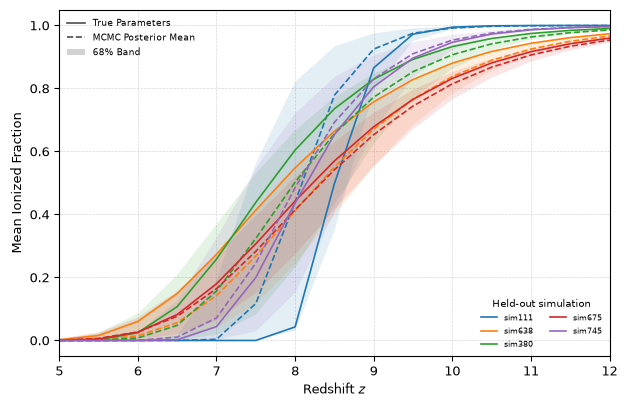

In [11]:
plot_cases(random_results, f"ionization_history_posterior_linearnd_random_{len(random_results)}_{EXPERIMENT_NAME}.pdf")

## Percent Error for Ionization History (Random Set)

In [12]:
random_errors = print_case_errors(random_results, "Random Set")

Random Set
	Test-Set Index  152 (sim111):	31.63%
	Test-Set Index   87 (sim638):	26.47%
	Test-Set Index  129 (sim380):	20.30%
	Test-Set Index   17 (sim675):	4.22%
	Test-Set Index   86 (sim745):	7.55%

	Mean:	18.03%
	STD:	11.85%
	Range:	4.22% to 31.63%


## Full Pipeline Over N Central Simulations

In [13]:
%%time

rng = np.random.default_rng(SEED)

case_idx = np.asarray(central_order[:N_CASES])
n_cases  = len(case_idx)

_dist_check = dist[case_idx]
assert np.all(np.diff(_dist_check) >= 0), ("case_idx is not ordered by distance to the center of parameter space")

print(f"Distances to centre: {np.round(_dist_check, 3).tolist()}")
print(f"Running the pipeline on {n_cases} central held-out cases:")
print(f"\ttest-set idx {case_idx.tolist()}")
print(f"\tglobal idx {heldout_indices[case_idx].tolist()}")

central_results = run_cases(case_idx, rng)

Distances to centre: [0.174, 0.197, 0.208, 0.226, 0.238]
Running the pipeline on 5 central held-out cases:
	test-set idx [37, 11, 30, 0, 90]
	global idx [106, 32, 450, 560, 111]

[1/5] test-set idx 37 - running 30,000 steps...


100%|██████████| 30000/30000 [35:49<00:00, 13.96it/s]


	acceptance=0.426 	 out-of-hull=9.2%

[2/5] test-set idx 11 - running 30,000 steps...


100%|██████████| 30000/30000 [35:45<00:00, 13.98it/s]


	acceptance=0.424 	 out-of-hull=7.0%

[3/5] test-set idx 30 - running 30,000 steps...


...

	acceptance=0.412 	 out-of-hull=8.2%

[4/5] test-set idx 0 - running 30,000 steps...


100%|██████████| 30000/30000 [35:04<00:00, 14.26it/s]


	acceptance=0.422 	 out-of-hull=8.5%

[5/5] test-set idx 90 - running 30,000 steps...


100%|██████████| 30000/30000 [35:05<00:00, 14.25it/s]

	acceptance=0.407 	 out-of-hull=8.6%
CPU times: user 2h 55min 34s, sys: 48.1 s, total: 2h 56min 22s
Wall time: 2h 56min 35s


## Plot N Central Simulations

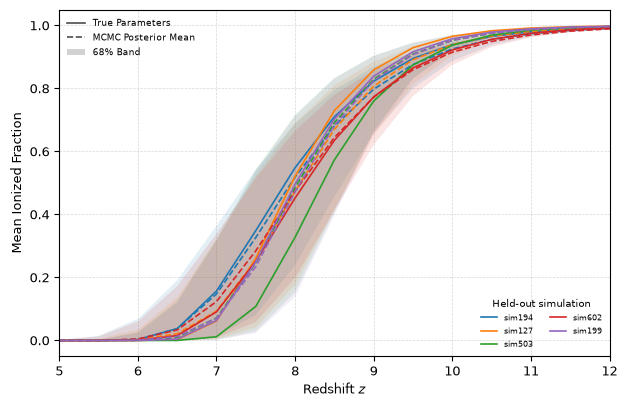

In [14]:
plot_cases(central_results, f"ionization_history_posterior_linearnd_best_{len(central_results)}_{EXPERIMENT_NAME}.pdf")

## Percent Error for Ionization History (Central Set)

In [15]:
central_errors = print_case_errors(central_results, "Central Set")

print()
print(f"Random Set Mean:\t{random_errors.mean():.2f}%")
print(f"Central Set Mean:\t{central_errors.mean():.2f}%")

Central Set
	Test-Set Index   37 (sim194):	4.05%
	Test-Set Index   11 (sim127):	13.40%
	Test-Set Index   30 (sim503):	35.36%
	Test-Set Index    0 (sim602):	8.13%
	Test-Set Index   90 (sim199):	4.53%

	Mean:	13.09%
	STD:	13.00%
	Range:	4.05% to 35.36%

Random Set Mean:	18.03%
Central Set Mean:	13.09%


## Save Records

In [16]:
batch_record = {"n_steps": NSTEPS, "n_walkers": NWALKERS, "discard": DISCARD, "thin": THIN}

for name, results in (("random", random_results), ("central", central_results)):
    errors = case_percent_errors(results)
    batch_record[name] = {
        "test_set_indices": [r["idx"] for r in results],
        "global_indices": [r["global_idx"] for r in results],
        "sim_names": [r["sim_name"] for r in results],
        "xe_percent_error_per_case": [float(e) for e in errors],
        "xe_percent_error_mean": float(errors.mean()),
        "xe_percent_error_std": float(errors.std(ddof=1)),
        "out_of_hull_fraction": [r["nan_frac"] for r in results],
    }

path = RECORDS_DIR / "mcmc_batch_cases.json"
with path.open("w", encoding="utf-8") as fh:
    json.dump(batch_record, fh, indent=4, sort_keys=True)
    fh.write("\n")

print(f"Batch Cases:\n{path}")

Batch Cases:
/Users/robertxpearce/Desktop/Research/LEADS Lab/reionemu/reionemu-pasa-2026/results/pearce_2026_reionemu_mc_dropout/n_mc_201_epochs_1000_early_stop_150/records/mcmc_batch_cases.json
